In [16]:
# Step 1: Import libraries

import pandas as pd
import numpy as np
import sqlite3
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)

print("Libraries imported successfully")

Libraries imported successfully


In [17]:
# Step 2: Set data folder

DATA_DIR = Path("/content")

print("Current data folder:", DATA_DIR)
print("Files in this folder:")

for file in DATA_DIR.glob("*.csv"):
    print(file.name)

Current data folder: /content
Files in this folder:
olist_products_dataset.csv
olist_order_reviews_dataset.csv
olist_orders_dataset.csv
product_category_name_translation.csv
olist_order_items_dataset.csv
olist_customers_dataset.csv
olist_order_payments_dataset.csv


In [18]:
# Step 3: Check whether all required dataset files exist

required_files = [
    "olist_customers_dataset.csv",
    "olist_orders_dataset.csv",
    "olist_order_items_dataset.csv",
    "olist_order_payments_dataset.csv",
    "olist_order_reviews_dataset.csv",
    "olist_products_dataset.csv",
    "product_category_name_translation.csv"
]

for file in required_files:
    if (DATA_DIR / file).exists():
        print("FOUND:", file)
    else:
        print("MISSING:", file)

FOUND: olist_customers_dataset.csv
FOUND: olist_orders_dataset.csv
FOUND: olist_order_items_dataset.csv
FOUND: olist_order_payments_dataset.csv
FOUND: olist_order_reviews_dataset.csv
FOUND: olist_products_dataset.csv
FOUND: product_category_name_translation.csv


In [19]:
# Step 4: Load CSV files into pandas DataFrames

customers = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv")
orders = pd.read_csv(DATA_DIR / "olist_orders_dataset.csv")
order_items = pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv")
payments = pd.read_csv(DATA_DIR / "olist_order_payments_dataset.csv")
reviews = pd.read_csv(DATA_DIR / "olist_order_reviews_dataset.csv")
products = pd.read_csv(DATA_DIR / "olist_products_dataset.csv")
category_translation = pd.read_csv(DATA_DIR / "product_category_name_translation.csv")

print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Order items:", order_items.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Products:", products.shape)
print("Category translation:", category_translation.shape)

Customers: (99441, 5)
Orders: (99441, 8)
Order items: (112650, 7)
Payments: (103886, 5)
Reviews: (99224, 7)
Products: (32951, 9)
Category translation: (71, 2)


## Dataset Loading Summary

The required Olist e-commerce datasets were successfully uploaded and loaded into Python.  
The dataset includes customer information, order details, product data, payment records, delivery information, and customer review scores.

These tables will be used to analyze:
- Monthly sales performance
- Top product categories
- Customer locations
- Delivery performance
- Customer satisfaction
- CRM-style customer segmentation

In [20]:
# Step 5: Preview important tables

print("Customers table:")
display(customers.head())

print("Orders table:")
display(orders.head())

print("Order items table:")
display(order_items.head())

print("Reviews table:")
display(reviews.head())

Customers table:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


Orders table:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


Order items table:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


Reviews table:


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [21]:
# Step 6: Check missing values and duplicates

tables = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "category_translation": category_translation
}

for name, df in tables.items():
    print("\n==============================")
    print(name.upper())
    print("==============================")
    print("Rows and columns:", df.shape)
    print("Duplicate rows:", df.duplicated().sum())
    print("Top missing values:")
    print(df.isnull().sum().sort_values(ascending=False).head())


CUSTOMERS
Rows and columns: (99441, 5)
Duplicate rows: 0
Top missing values:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

ORDERS
Rows and columns: (99441, 8)
Duplicate rows: 0
Top missing values:
order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
order_id                            0
order_purchase_timestamp            0
dtype: int64

ORDER_ITEMS
Rows and columns: (112650, 7)
Duplicate rows: 0
Top missing values:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
dtype: int64

PAYMENTS
Rows and columns: (103886, 5)
Duplicate rows: 0
Top missing values:
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

REVIEWS
Rows and columns: (99224, 7)
Dup

In [22]:
# Step 7: Convert date columns in orders table

date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

print("Date columns converted successfully")
orders[date_columns].head()

Date columns converted successfully


,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [23]:
# Step 8: Create SQLite database

conn = sqlite3.connect("olist_ecommerce.db")

customers.to_sql("customers", conn, if_exists="replace", index=False)
orders.to_sql("orders", conn, if_exists="replace", index=False)
order_items.to_sql("order_items", conn, if_exists="replace", index=False)
payments.to_sql("payments", conn, if_exists="replace", index=False)
reviews.to_sql("reviews", conn, if_exists="replace", index=False)
products.to_sql("products", conn, if_exists="replace", index=False)
category_translation.to_sql("category_translation", conn, if_exists="replace", index=False)

print("SQLite database created successfully")

SQLite database created successfully


In [24]:
# Step 9: SQL analysis - monthly sales trend

query = """
SELECT
    strftime('%Y-%m', o.order_purchase_timestamp) AS order_month,
    COUNT(DISTINCT o.order_id) AS total_orders,
    ROUND(SUM(oi.price + oi.freight_value), 2) AS total_revenue
FROM orders o
JOIN order_items oi
    ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
GROUP BY order_month
ORDER BY order_month;
"""

monthly_sales = pd.read_sql_query(query, conn)

display(monthly_sales.head())

,order_month,total_orders,total_revenue
0,2016-09,1,143.46
1,2016-10,265,46490.66
2,2016-12,1,19.62
3,2017-01,750,127482.37
4,2017-02,1653,271239.32


In [25]:
# Step 10: SQL analysis - top product categories by revenue

query = """
SELECT
    COALESCE(ct.product_category_name_english, p.product_category_name) AS product_category,
    COUNT(DISTINCT oi.order_id) AS total_orders,
    ROUND(SUM(oi.price + oi.freight_value), 2) AS total_revenue
FROM order_items oi
JOIN products p
    ON oi.product_id = p.product_id
LEFT JOIN category_translation ct
    ON p.product_category_name = ct.product_category_name
GROUP BY product_category
ORDER BY total_revenue DESC
LIMIT 10;
"""

top_categories = pd.read_sql_query(query, conn)

display(top_categories)

,product_category,total_orders,total_revenue
0,health_beauty,8836,1441248.07
1,watches_gifts,5624,1305541.61
2,bed_bath_table,9417,1241681.72
3,sports_leisure,7720,1156656.48
4,computers_accessories,6689,1059272.40
5,furniture_decor,6449,902511.79
6,housewares,5884,778397.77
7,cool_stuff,3632,719329.95
8,auto,3897,685384.32
9,garden_tools,3518,584219.21


In [26]:
# Step 11: SQL analysis - sales by customer state

query = """
SELECT
    c.customer_state,
    COUNT(DISTINCT o.order_id) AS total_orders,
    COUNT(DISTINCT c.customer_unique_id) AS unique_customers,
    ROUND(SUM(oi.price + oi.freight_value), 2) AS total_revenue
FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
JOIN order_items oi
    ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_state
ORDER BY total_revenue DESC;
"""

state_sales = pd.read_sql_query(query, conn)

display(state_sales.head(10))

,customer_state,total_orders,unique_customers,total_revenue
0,SP,40501,39156,5769703.15
1,RJ,12350,11917,2055401.57
2,MG,11354,11001,1818891.67
3,RS,5345,5168,861472.79
4,PR,4923,4769,781708.80
5,SC,3546,3449,595127.78
6,BA,3256,3158,591137.81
7,DF,2080,2019,346123.35
8,GO,1957,1895,334212.35
9,ES,1995,1928,317657.93


In [27]:
# Step 12: SQL analysis - delivery status and customer review

query = """
SELECT
    CASE
        WHEN julianday(o.order_delivered_customer_date) <= julianday(o.order_estimated_delivery_date)
        THEN 'On-time'
        ELSE 'Late'
    END AS delivery_status,
    COUNT(DISTINCT o.order_id) AS total_orders,
    ROUND(AVG(r.review_score), 2) AS avg_review_score
FROM orders o
JOIN reviews r
    ON o.order_id = r.order_id
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
GROUP BY delivery_status;
"""

delivery_reviews = pd.read_sql_query(query, conn)

display(delivery_reviews)

,delivery_status,total_orders,avg_review_score
0,Late,7661,2.57
1,On-time,88163,4.29


In [28]:
# Step 13: Create clean order-level dataset for Python analysis and Power BI

# Calculate order revenue from order_items
order_revenue = order_items.groupby("order_id", as_index=False).agg(
    total_price=("price", "sum"),
    total_freight=("freight_value", "sum")
)

order_revenue["total_revenue"] = order_revenue["total_price"] + order_revenue["total_freight"]

# Average review score per order
review_scores = reviews.groupby("order_id", as_index=False).agg(
    review_score=("review_score", "mean")
)

# Combine orders, customers, revenue, and reviews
order_clean = orders.merge(customers, on="customer_id", how="left")
order_clean = order_clean.merge(order_revenue, on="order_id", how="left")
order_clean = order_clean.merge(review_scores, on="order_id", how="left")

# Create useful columns
order_clean["delivery_days"] = (
    order_clean["order_delivered_customer_date"] - order_clean["order_purchase_timestamp"]
).dt.days

order_clean["delay_days"] = (
    order_clean["order_delivered_customer_date"] - order_clean["order_estimated_delivery_date"]
).dt.days

order_clean["delivery_status"] = np.where(
    order_clean["delay_days"] <= 0,
    "On-time",
    "Late"
)

order_clean["order_month"] = order_clean["order_purchase_timestamp"].dt.to_period("M").astype(str)

display(order_clean.head())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_price,total_freight,total_revenue,review_score,delivery_days,delay_days,delivery_status,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,29.99,8.72,38.71,4.0,8.0,-8.0,On-time,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,118.70,22.76,141.46,4.0,13.0,-6.0,On-time,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,159.90,19.22,179.12,5.0,9.0,-18.0,On-time,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,45.00,27.20,72.20,5.0,13.0,-13.0,On-time,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,19.90,8.72,28.62,5.0,2.0,-10.0,On-time,2018-02


In [29]:
# Step 14: Create simple customer segmentation

# Use only delivered orders with revenue
delivered_orders = order_clean[
    (order_clean["order_status"] == "delivered") &
    (order_clean["total_revenue"].notnull())
].copy()

# Set reference date as one day after the latest order
reference_date = delivered_orders["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

customer_segments = delivered_orders.groupby("customer_unique_id", as_index=False).agg(
    last_purchase_date=("order_purchase_timestamp", "max"),
    total_orders=("order_id", "nunique"),
    total_spent=("total_revenue", "sum"),
    avg_review_score=("review_score", "mean")
)

customer_segments["recency_days"] = (
    reference_date - customer_segments["last_purchase_date"]
).dt.days

# Simple segmentation rules
spent_75 = customer_segments["total_spent"].quantile(0.75)
spent_50 = customer_segments["total_spent"].quantile(0.50)
recency_50 = customer_segments["recency_days"].quantile(0.50)

def assign_segment(row):
    if row["total_spent"] >= spent_75 and row["total_orders"] >= 2:
        return "High Value Customers"
    elif row["total_orders"] >= 2:
        return "Repeat Customers"
    elif row["recency_days"] <= recency_50:
        return "Recent One-Time Customers"
    elif row["total_spent"] >= spent_50:
        return "At Risk Valuable Customers"
    else:
        return "Low Engagement Customers"

customer_segments["customer_segment"] = customer_segments.apply(assign_segment, axis=1)

display(customer_segments.head())

,customer_unique_id,last_purchase_date,total_orders,total_spent,avg_review_score,recency_days,customer_segment
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90,5.0,112,Recent One-Time Customers
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19,4.0,115,Recent One-Time Customers
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22,3.0,537,Low Engagement Customers
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62,4.0,321,Low Engagement Customers
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89,5.0,288,At Risk Valuable Customers


In [30]:
# Step 15: Customer segment summary

segment_summary = customer_segments.groupby("customer_segment", as_index=False).agg(
    number_of_customers=("customer_unique_id", "count"),
    avg_total_spent=("total_spent", "mean"),
    avg_orders=("total_orders", "mean"),
    avg_recency_days=("recency_days", "mean"),
    avg_review_score=("avg_review_score", "mean")
)

segment_summary = segment_summary.sort_values("number_of_customers", ascending=False)

display(segment_summary)

,customer_segment,number_of_customers,avg_total_spent,avg_orders,avg_recency_days,avg_review_score
3,Recent One-Time Customers,45298,161.635575,1.000000,112.123847,4.140334
2,Low Engagement Customers,23502,63.669086,1.000000,365.145562,4.210819
0,At Risk Valuable Customers,21757,263.706722,1.000000,364.760123,4.112819
1,High Value Customers,1772,415.243397,2.155756,213.603837,4.165866
4,Repeat Customers,1029,124.758173,2.041788,231.816327,4.273756


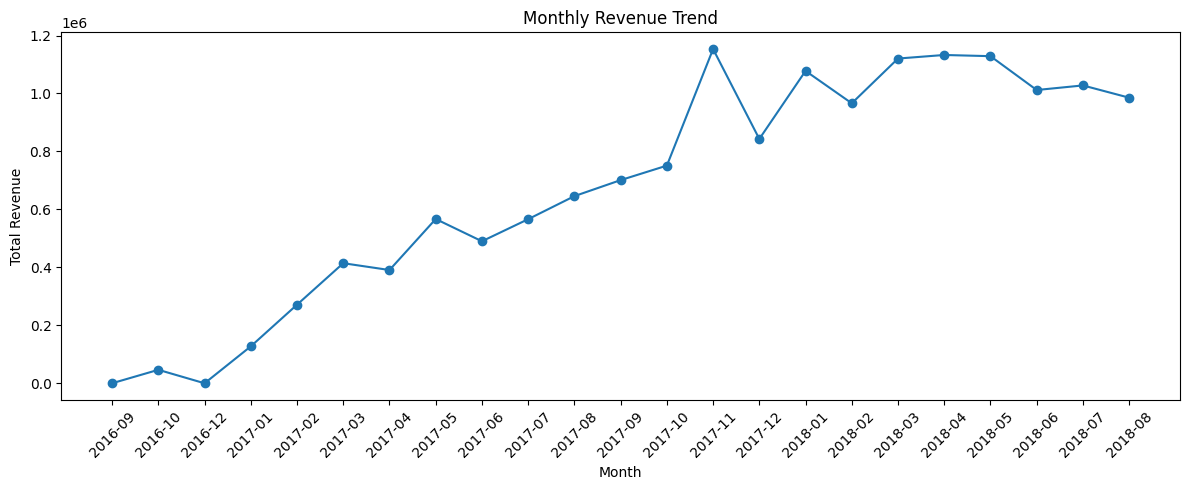

In [31]:
# Step 16: Monthly sales chart

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales["order_month"], monthly_sales["total_revenue"], marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

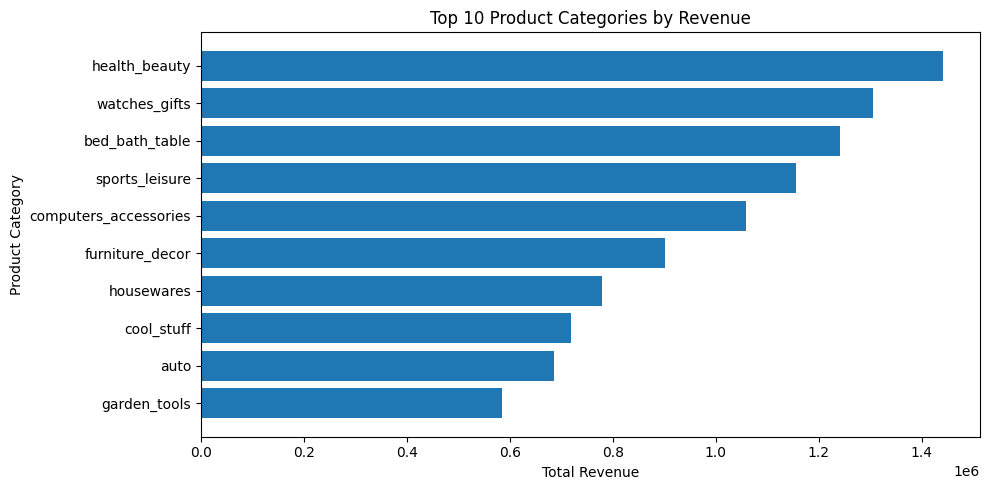

In [32]:
# Step 17: Top product categories chart

plt.figure(figsize=(10, 5))
plt.barh(top_categories["product_category"], top_categories["total_revenue"])
plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product Category")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

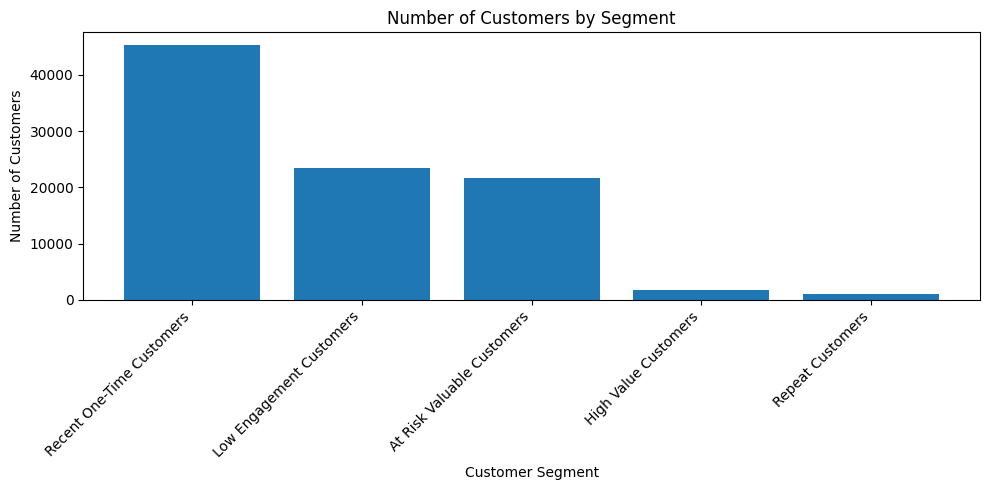

In [34]:
# Step 18: Customer segment chart

plt.figure(figsize=(10, 5))
plt.bar(segment_summary["customer_segment"], segment_summary["number_of_customers"])
plt.title("Number of Customers by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [37]:
# Step 19: Export clean files for Power BI

output_folder = Path("/content/processed_data")
output_folder.mkdir(exist_ok=True)

order_clean.to_csv(output_folder / "order_clean.csv", index=False)
monthly_sales.to_csv(output_folder / "monthly_sales.csv", index=False)
top_categories.to_csv(output_folder / "top_categories.csv", index=False)
state_sales.to_csv(output_folder / "state_sales.csv", index=False)
delivery_reviews.to_csv(output_folder / "delivery_reviews.csv", index=False)
customer_segments.to_csv(output_folder / "customer_segments.csv", index=False)
segment_summary.to_csv(output_folder / "segment_summary.csv", index=False)

print("Files exported successfully to:", output_folder)

Files exported successfully to: /content/processed_data


In [38]:
# Step 20: Zip processed files so you can download them

import shutil

shutil.make_archive("/content/processed_data_for_powerbi", "zip", output_folder)

print("ZIP file created: processed_data_for_powerbi.zip")

ZIP file created: processed_data_for_powerbi.zip


## Business Insights Summary

This project analyzed Olist e-commerce data to understand sales performance, customer behavior, product performance, delivery experience, and customer satisfaction.

### Key Findings

1. **Sales Performance**
   - Monthly revenue and order volume showed clear growth across the available period.
   - This helps the business understand sales trends and seasonal performance.

2. **Top Product Categories**
   - The highest revenue categories included health & beauty, watches & gifts, bed/bath/table, sports/leisure, and computer accessories.
   - These categories can be prioritized for marketing campaigns and inventory planning.

3. **Customer Location**
   - São Paulo (SP), Rio de Janeiro (RJ), and Minas Gerais (MG) generated the highest revenue.
   - These states are important markets for customer acquisition and retention strategies.

4. **Delivery & Customer Satisfaction**
   - On-time deliveries had a much higher average review score than late deliveries.
   - This suggests delivery performance is strongly connected to customer satisfaction.

5. **CRM Opportunity**
   - Customers were segmented into groups such as High Value Customers, Repeat Customers, Recent One-Time Customers, At Risk Valuable Customers, and Low Engagement Customers.
   - These segments can support targeted CRM campaigns such as loyalty rewards, reactivation campaigns, and onboarding campaigns.